<a href="https://colab.research.google.com/github/jagadeeshkaparapu626-cmyk/Hospital-Ward-Staffing-Optimizer/blob/main/Jagadeesh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# HOSPITAL WARD STAFFING OPTIMIZER (A1)
# B.Tech Mathematics Mini Project
# Method: System of Linear Equations + Gauss Elimination
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. USER CONFIGURATION
# ------------------------------------------------------------

# Required staff-hours for each ward
ward_names = ["Ward A", "Ward B", "Ward C"]

B = np.array([
    20,   # Ward A requirement
    25,   # Ward B requirement
    15    # Ward C requirement
], dtype=float)

# Staff types
staff_names = ["Senior Nurse", "Junior Nurse", "Assistant"]

# Hourly cost (Rs/hour)
cost_per_hour = np.array([
    800,   # Senior Nurse
    400,   # Junior Nurse
    200    # Assistant
], dtype=float)

# ------------------------------------------------------------
# STAFF-HOUR CONTRIBUTION MATRIX A
#
# Rows    = Wards
# Columns = Staff types
#
# A[i,j] = effective hours contributed to ward i
#          by one staffing unit of staff type j.
#
# This is the benchmark dataset assumption.
# Change these values for your hospital/project data.
# ------------------------------------------------------------

A = np.array([
    [8, 5, 2],   # Ward A
    [5, 8, 4],   # Ward B
    [3, 4, 4]    # Ward C
], dtype=float)


# ------------------------------------------------------------
# 2. DISPLAY THE MATHEMATICAL MODEL
# ------------------------------------------------------------

print("=" * 65)
print("      HOSPITAL WARD STAFFING OPTIMIZER")
print("=" * 65)

print("\nStaff Types:")
for name, cost in zip(staff_names, cost_per_hour):
    print(f"  {name:<15} : Rs.{cost:.0f}/hour")

print("\nWard Requirements:")
for ward, requirement in zip(ward_names, B):
    print(f"  {ward:<10} : {requirement:.0f} staff-hours")

print("\nContribution Matrix A:")
print(A)

print("\nRequirement Vector B:")
print(B)

print("\nMathematical Model:")
print("             A × X = B")

print("\nTherefore:")

print(f"  {A[0,0]:.0f}x₁ + {A[0,1]:.0f}x₂ + {A[0,2]:.0f}x₃ = {B[0]:.0f}")
print(f"  {A[1,0]:.0f}x₁ + {A[1,1]:.0f}x₂ + {A[1,2]:.0f}x₃ = {B[1]:.0f}")
print(f"  {A[2,0]:.0f}x₁ + {A[2,1]:.0f}x₂ + {A[2,2]:.0f}x₃ = {B[2]:.0f}")

print("\nWhere:")
print("  x₁ = Senior Nurses")
print("  x₂ = Junior Nurses")
print("  x₃ = Assistants")


# ------------------------------------------------------------
# 3. GAUSS ELIMINATION
# ------------------------------------------------------------

def gauss_elimination(A, B):
    """
    Solve AX = B using Gaussian elimination.

    Steps:
    1. Create augmented matrix [A | B]
    2. Forward elimination
    3. Back substitution
    """

    A = A.astype(float)
    B = B.astype(float)

    n = len(B)

    # Augmented matrix [A | B]
    M = np.column_stack((A, B))

    print("\n" + "=" * 65)
    print("GAUSS ELIMINATION - STEP BY STEP")
    print("=" * 65)

    print("\nInitial Augmented Matrix [A | B]:")
    print(M)

    # --------------------------------------------------------
    # Forward Elimination
    # --------------------------------------------------------

    for i in range(n):

        # Find pivot
        max_row = i + np.argmax(np.abs(M[i:, i]))

        if abs(M[max_row, i]) < 1e-12:
            raise ValueError(
                "The system does not have a unique solution."
            )

        # Swap rows if required
        if max_row != i:
            M[[i, max_row]] = M[[max_row, i]]

            print(f"\nR{i+1} ↔ R{max_row+1}")
            print(M)

        # Eliminate values below pivot
        for j in range(i + 1, n):

            factor = M[j, i] / M[i, i]

            M[j] = M[j] - factor * M[i]

            print(
                f"\nR{j+1} → R{j+1} - "
                f"({factor:.3f})R{i+1}"
            )
            print(np.round(M, 4))

    # --------------------------------------------------------
    # Back Substitution
    # --------------------------------------------------------

    x = np.zeros(n)

    for i in range(n - 1, -1, -1):

        x[i] = (
            M[i, -1]
            - np.dot(M[i, i+1:n], x[i+1:n])
        ) / M[i, i]

    print("\nUpper Triangular Matrix:")
    print(np.round(M, 4))

    print("\nBack Substitution Result:")
    for i in range(n):
        print(f"x{i+1} = {x[i]:.4f}")

    return x


# Solve the system
X = gauss_elimination(A, B)

      HOSPITAL WARD STAFFING OPTIMIZER

Staff Types:
  Senior Nurse    : Rs.800/hour
  Junior Nurse    : Rs.400/hour
  Assistant       : Rs.200/hour

Ward Requirements:
  Ward A     : 20 staff-hours
  Ward B     : 25 staff-hours
  Ward C     : 15 staff-hours

Contribution Matrix A:
[[8. 5. 2.]
 [5. 8. 4.]
 [3. 4. 4.]]

Requirement Vector B:
[20. 25. 15.]

Mathematical Model:
             A × X = B

Therefore:
  8x₁ + 5x₂ + 2x₃ = 20
  5x₁ + 8x₂ + 4x₃ = 25
  3x₁ + 4x₂ + 4x₃ = 15

Where:
  x₁ = Senior Nurses
  x₂ = Junior Nurses
  x₃ = Assistants

GAUSS ELIMINATION - STEP BY STEP

Initial Augmented Matrix [A | B]:
[[ 8.  5.  2. 20.]
 [ 5.  8.  4. 25.]
 [ 3.  4.  4. 15.]]

R2 → R2 - (0.625)R1
[[ 8.     5.     2.    20.   ]
 [ 0.     4.875  2.75  12.5  ]
 [ 3.     4.     4.    15.   ]]

R3 → R3 - (0.375)R1
[[ 8.     5.     2.    20.   ]
 [ 0.     4.875  2.75  12.5  ]
 [ 0.     2.125  3.25   7.5  ]]

R3 → R3 - (0.436)R2
[[ 8.      5.      2.     20.    ]
 [ 0.      4.875   2.75   12.5   ]
 [


FINAL STAFFING SOLUTION
Senior Nurse        : 1.0000 units
Junior Nurse        : 2.0000 units
Assistant           : 1.0000 units

WARD REQUIREMENT VERIFICATION
Ward A     | Required =   20.00 | Provided =   20.00 | Difference =    0.00
Ward B     | Required =   25.00 | Provided =   25.00 | Difference =    0.00
Ward C     | Required =   15.00 | Provided =   15.00 | Difference =    0.00

STAFFING COST
Senior Nurse         | Hours =    16.00 | Cost = Rs.  12800.00
Junior Nurse         | Hours =    34.00 | Cost = Rs.  13600.00
Assistant            | Hours =    10.00 | Cost = Rs.   2000.00
-----------------------------------------------------------------
TOTAL COST           : Rs.28,400.00

SYMPY VERIFICATION

Solution using SymPy:
⎡0.999999999999999⎤
⎢                 ⎥
⎢       2.0       ⎥
⎢                 ⎥
⎣0.999999999999999⎦

FINAL RESULTS TABLE
Staff Type                 Units       Hours    Hourly Cost     Total Cost
------------------------------------------------------------------

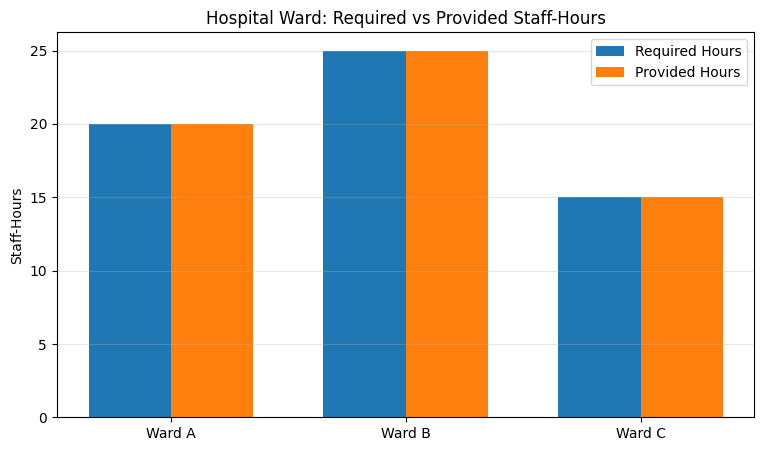

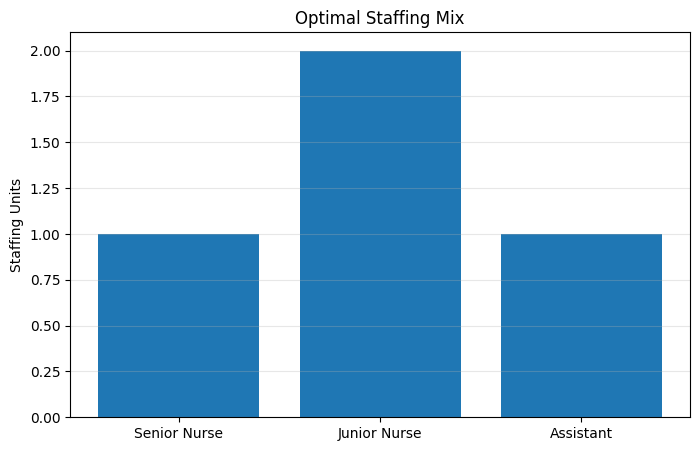

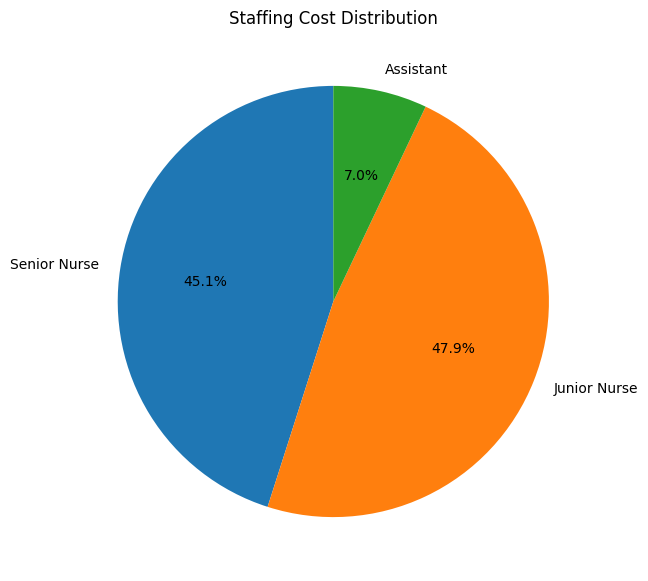


PROJECT CONCLUSION

The hospital staffing problem was represented as:

                  A × X = B

Gaussian elimination was used to solve the system.

The resulting values of X give the staffing mix required
to satisfy the three ward requirements.

The total staffing cost was then calculated using the
hourly cost of each staff type.

Important:
Gauss elimination solves the linear equations. It does not
by itself search through alternative solutions to minimize
cost. If the hospital model has multiple feasible staffing
combinations, Linear Programming should be added for true
cost optimization.



In [ ]:
# ============================================================
# 4. RESULT + COST + VERIFICATION + VISUALIZATION
# ============================================================

print("\n" + "=" * 65)
print("FINAL STAFFING SOLUTION")
print("=" * 65)

# ------------------------------------------------------------
# Staffing solution
# ------------------------------------------------------------

for name, value in zip(staff_names, X):
    print(f"{name:<20}: {value:.4f} units")


# ------------------------------------------------------------
# 5. VERIFY AX = B
# ------------------------------------------------------------

calculated_hours = A @ X

print("\n" + "=" * 65)
print("WARD REQUIREMENT VERIFICATION")
print("=" * 65)

for i in range(len(ward_names)):

    print(
        f"{ward_names[i]:<10} | "
        f"Required = {B[i]:>7.2f} | "
        f"Provided = {calculated_hours[i]:>7.2f} | "
        f"Difference = {calculated_hours[i] - B[i]:>7.2f}"
    )


# ------------------------------------------------------------
# 6. COST CALCULATION
# ------------------------------------------------------------
#
# For each staff type:
#
# Total hours = sum of its contribution across all wards
# Cost = total hours × hourly rate
#
# ------------------------------------------------------------

hours_by_staff = np.sum(A, axis=0) * X

cost_by_staff = hours_by_staff * cost_per_hour

total_cost = np.sum(cost_by_staff)

print("\n" + "=" * 65)
print("STAFFING COST")
print("=" * 65)

for i in range(len(staff_names)):

    print(
        f"{staff_names[i]:<20} | "
        f"Hours = {hours_by_staff[i]:>8.2f} | "
        f"Cost = Rs.{cost_by_staff[i]:>10.2f}"
    )

print("-" * 65)
print(f"{'TOTAL COST':<20} : Rs.{total_cost:,.2f}")


# ------------------------------------------------------------
# 7. SYMPY VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SYMPY VERIFICATION")
print("=" * 65)

A_sym = sp.Matrix(A)
B_sym = sp.Matrix(B)

solution_sym = A_sym.inv() * B_sym

print("\nSolution using SymPy:")
sp.pprint(solution_sym)


# ------------------------------------------------------------
# 8. RESULTS TABLE
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL RESULTS TABLE")
print("=" * 65)

print(
    f"{'Staff Type':<20}"
    f"{'Units':>12}"
    f"{'Hours':>12}"
    f"{'Hourly Cost':>15}"
    f"{'Total Cost':>15}"
)

print("-" * 75)

for i in range(len(staff_names)):

    print(
        f"{staff_names[i]:<20}"
        f"{X[i]:>12.2f}"
        f"{hours_by_staff[i]:>12.2f}"
        f"Rs.{cost_per_hour[i]:>11.0f}"
        f"Rs.{cost_by_staff[i]:>12.2f}"
    )

print("-" * 75)

print(
    f"{'TOTAL':<20}"
    f"{np.sum(X):>12.2f}"
    f"{np.sum(hours_by_staff):>12.2f}"
    f"{'':>15}"
    f"Rs.{total_cost:>12.2f}"
)


# ============================================================
# 9. VISUALIZATION 1
# Required vs Provided Staff-Hours
# ============================================================

plt.figure(figsize=(9, 5))

x_pos = np.arange(len(ward_names))
width = 0.35

plt.bar(
    x_pos - width/2,
    B,
    width,
    label="Required Hours"
)

plt.bar(
    x_pos + width/2,
    calculated_hours,
    width,
    label="Provided Hours"
)

plt.xticks(x_pos, ward_names)
plt.ylabel("Staff-Hours")
plt.title("Hospital Ward: Required vs Provided Staff-Hours")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()


# ============================================================
# 10. VISUALIZATION 2
# Staffing Mix
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    staff_names,
    X
)

plt.ylabel("Staffing Units")
plt.title("Optimal Staffing Mix")

plt.grid(axis="y", alpha=0.3)

plt.show()


# ============================================================
# 11. VISUALIZATION 3
# Cost Distribution
# ============================================================

plt.figure(figsize=(7, 7))

plt.pie(
    cost_by_staff,
    labels=staff_names,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Staffing Cost Distribution")

plt.show()


# ============================================================
# 12. FINAL PROJECT CONCLUSION
# ============================================================

print("\n" + "=" * 65)
print("PROJECT CONCLUSION")
print("=" * 65)

print("""
The hospital staffing problem was represented as:

                  A × X = B

Gaussian elimination was used to solve the system.

The resulting values of X give the staffing mix required
to satisfy the three ward requirements.

The total staffing cost was then calculated using the
hourly cost of each staff type.

Important:
Gauss elimination solves the linear equations. It does not
by itself search through alternative solutions to minimize
cost. If the hospital model has multiple feasible staffing
combinations, Linear Programming should be added for true
cost optimization.
""")